In [2]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from dynamax.hidden_markov_model import PoissonHMM
import seaborn as sns
import numpy as np

sns.set_context("notebook")


In [ ]:
#key1, key2, key3 = jr.split(jr.PRNGKey(0), 3)


key1, key2, key3 = jr.split(jr.PRNGKey(0), 3)

num_states = 3
emission_dim = 2
num_timesteps = 100

# Make a Poisson HMM and sample data from it
hmm = PoissonHMM(num_states, emission_dim)
true_params, _ = hmm.initialize(key1)

true_states, emissions = hmm.sample(true_params, key2, num_timesteps)




[[0.33429268 0.61131614 0.05439116]]
[[0.1502172  0.20967346 0.64010936]
 [0.31764594 0.47232494 0.2100292 ]
 [0.39592263 0.19531211 0.40876526]]
[[20.23178   5.826885]
 [15.743334 13.345718]
 [ 9.781236  5.868926]]


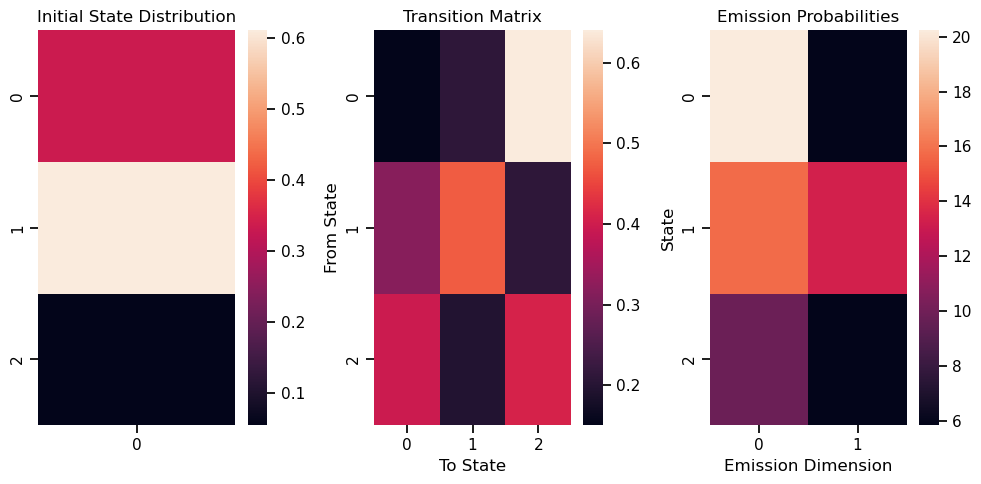

In [35]:
initial = np.array(true_params.initial)
transitions = np.array(true_params.transitions).squeeze()
emission_prob = np.array(true_params.emissions).squeeze()

print(initial)
print(transitions)
print(emission_prob)

fig, axs = plt.subplots(1, 3, figsize=(10, 5))
sns.heatmap(initial.T, ax=axs[0])
sns.heatmap(transitions, ax=axs[1])
sns.heatmap(emission_prob, ax=axs[2])
axs[0].set_title("Initial State Distribution")
axs[1].set_title("Transition Matrix")
axs[1].set_xlabel("To State")
axs[1].set_ylabel("From State")
axs[2].set_title("Emission Probabilities")
axs[2].set_xlabel("Emission Dimension")
axs[2].set_ylabel("State")
plt.tight_layout()
plt.show()

<div><progress max="20" value="20"></progress> 100.00% [20/20 00:00&lt;00:00]</div>

(100, 3)


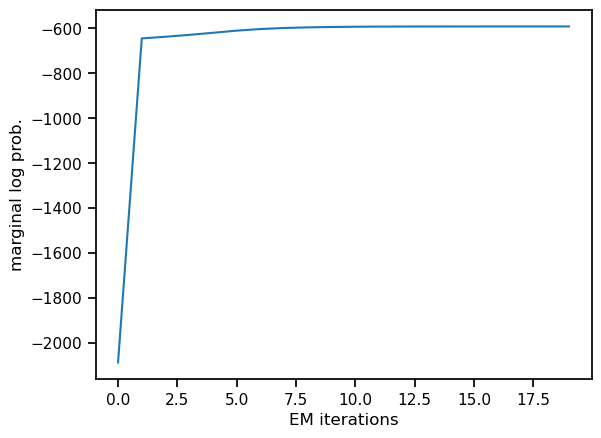

In [ ]:

# Make a new Poisson HMM and fit it with EM
params, props = hmm.initialize(key3)
params, lls = hmm.fit_em(params, props, emissions, num_iters=20)

# Plot the marginal log probs across EM iterations
plt.plot(lls)
plt.xlabel("EM iterations")
plt.ylabel("marginal log prob.")

# Use fitted model for posterior inference
post = hmm.smoother(params, emissions)
print(post.smoothed_probs.shape) # (100, 3)

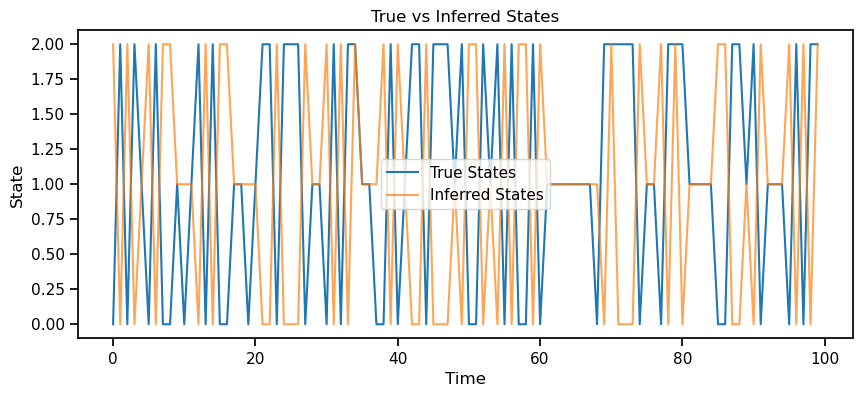

In [37]:
# plot the true and inferred states
plt.figure(figsize=(10, 4))
plt.plot(true_states, label="True States")
plt.plot(jnp.argmax(post.smoothed_probs, axis=1), label="Inferred States", alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("State")
plt.title("True vs Inferred States")
plt.show()


alpha: 0.2, beta: 0.96, gamma: 0.04


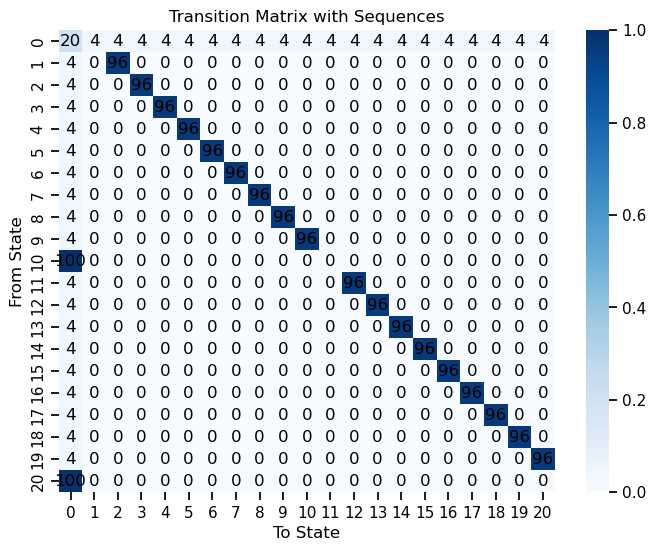

In [26]:
# make a transition matrix with a different structure and see if we can recover it

alpha = 0.2 # this is the probability of staying in the non sequence state. This is the only free parameter we have to set, the rest of the transition probabilities are determined by this and the sequence length and number of sequences


sequenceLength = 10 # number of latent states in each sequence
nSequences = 2 # total number of sequences

# the total number of states is the number of sequences times the sequence length and we add one for the non-sequence state
nStates = sequenceLength * nSequences + 1

gamma = (1 - alpha) / (nStates - 1) # this is the probability of transitioning into or out of any of the sequence states
beta = 1 - gamma # this is the probability of transitioning between states in the sequence
print(f"alpha: {alpha}, beta: {beta}, gamma: {gamma}")

# initialize the transition matrix with zeros and then fill in the appropriate entries
P = np.zeros((nStates, nStates))
P[0, 0] = alpha





# define the transition probabilities into the sequences (can transition into any part of the sequence with equal probability)
P[0, 1:] = gamma

# define the transition probabilities out of the sequences (can transition out of any part of the sequence with equal probability)
P[1:, 0] = gamma


# define the transition probabilities through the sequences
for i in range(nSequences):
    start = 1 + i * sequenceLength
    end = start + sequenceLength
    for j in range(start, end):
        if j == end - 1:
            P[j, 0] = 1 # transition from the last state in the sequence back to the first state in the sequence
        else:
            P[j, j + 1] = beta # transition from one state in the sequence to the next state in the sequence



plt.figure(figsize=(8, 6))
sns.heatmap(P, cmap="Blues")
# overlay the numbers for the transition probabilities
for i in range(nStates):
    for j in range(nStates):
        plt.text(j + 0.5, i + 0.5, f"{(P[i, j] * 100):.0f}", ha="center", va="center", color="black")
plt.title("Transition Matrix with Sequences")
plt.xlabel("To State")
plt.ylabel("From State")
plt.show()

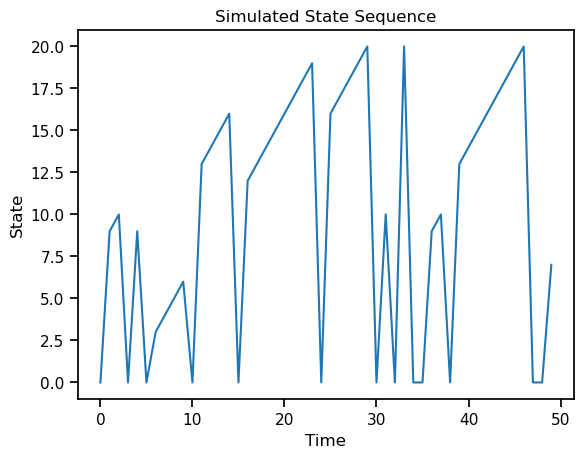

In [27]:
# simulate data from this transition matrix
Nsteps = 5000
states = np.zeros(Nsteps, dtype=int)
for t in range(1, Nsteps):
    states[t] = np.random.choice(nStates, p=P[states[t-1]])

plt.figure()
plt.plot(states[:50])
plt.title("Simulated State Sequence")
plt.xlabel("Time")
plt.ylabel("State")
plt.show()


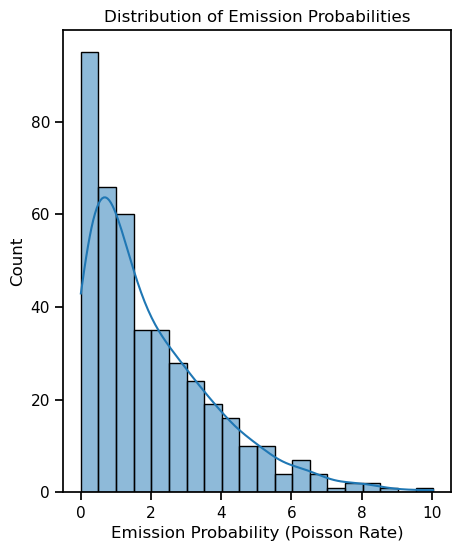

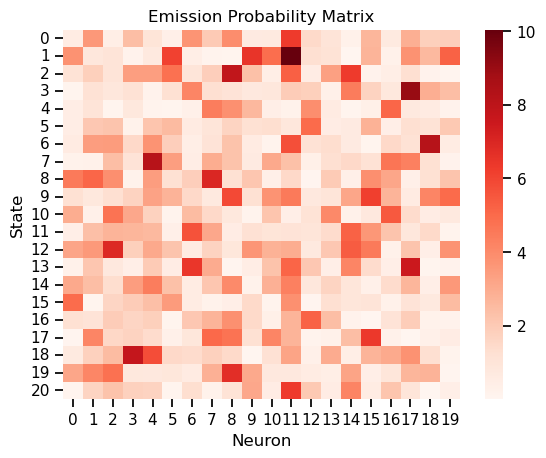

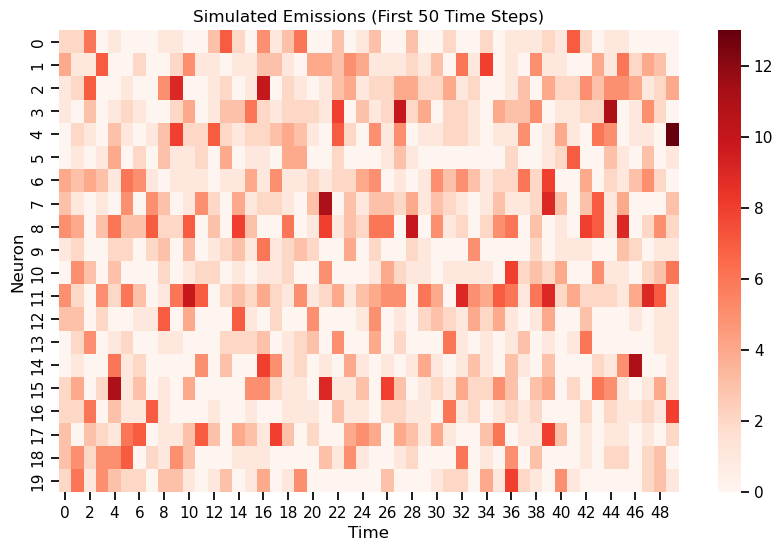

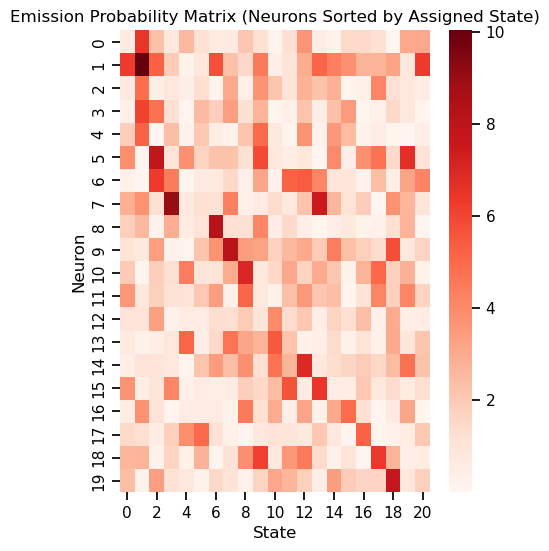

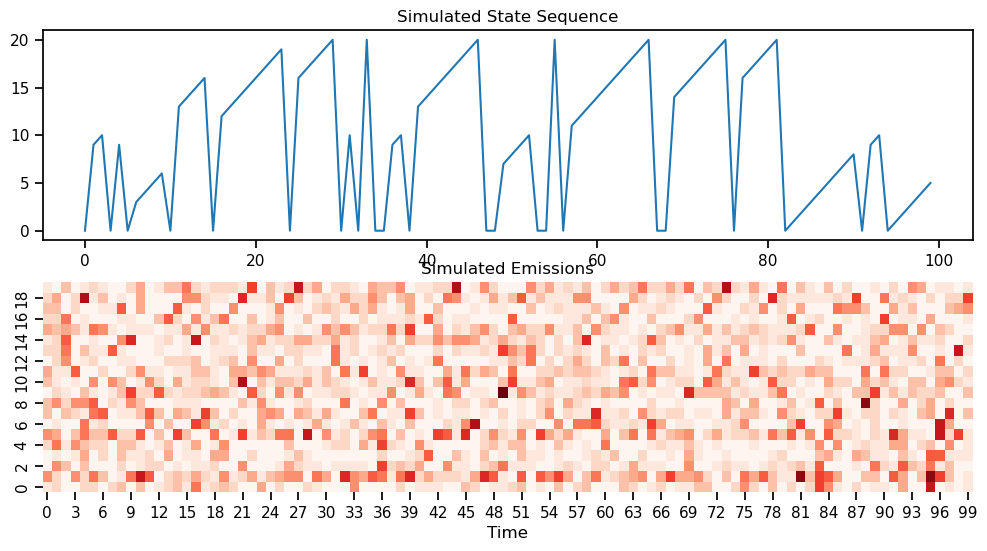

In [35]:
plot_len = 100

# randomly initialize the emission probabilities (poisson rates for each state and each neuron)
emission_dim = 20 # this corresponds to the number of neurons we are simulating

# draw the lambda parameters for the Poisson emissions from a gamma distribution (this is a common choice for a prior on Poisson rates)
emission_prob = np.random.gamma(shape=1, scale=2, size=(nStates, emission_dim))

# plot the distribution of emission probabilities for each state
plt.figure(figsize=(5, 6))
sns.histplot(emission_prob.flatten(), bins=20, kde=True)
plt.title("Distribution of Emission Probabilities")
plt.xlabel("Emission Probability (Poisson Rate)")
plt.ylabel("Count")
plt.show()

# simulate emissions from the HMM given the state sequence and the emission probabilities
emissions = np.zeros((Nsteps, emission_dim), dtype=int)
for t in range(Nsteps):
    emissions[t] = np.random.poisson(lam=emission_prob[states[t]])


# plot the emission prob matrix
plt.figure()
sns.heatmap(emission_prob, cmap="Reds")
plt.title("Emission Probability Matrix")
plt.xlabel("Neuron")
plt.ylabel("State")
plt.show()

# plot the emissions for the first 50 time steps
plt.figure(figsize=(10, 6))
sns.heatmap(emissions[:50].T, cmap="Reds")
plt.title("Simulated Emissions (First 50 Time Steps)")
plt.xlabel("Time")
plt.ylabel("Neuron")
plt.show()

# assign neurons to states (for each neuron, the state of maximal firing is the state that neuron is assigned to)
neuron_states = np.argmax(emission_prob, axis=0)

# sort the neurons by their assigned states and plot the emision prob matrix again
sorted_indices = np.argsort(neuron_states)
plt.figure(figsize=(5, 6))
sns.heatmap(emission_prob[:, sorted_indices].T, cmap="Reds")
plt.title("Emission Probability Matrix (Neurons Sorted by Assigned State)")
plt.xlabel("State")
plt.ylabel("Neuron")
plt.show()






# sort the neurons by their assigned states and plot the emissions again
sorted_indices = np.argsort(neuron_states)
fig, axs = plt.subplots(2, 1, figsize=(12, 6))
sns.lineplot(x=np.arange(plot_len), y=states[:plot_len], ax=axs[0])
axs[0].set_title("Simulated State Sequence")
sns.heatmap(emissions[:plot_len, sorted_indices].T, cmap="Reds", ax=axs[1])
# flip the y axis so that neuron 0 is at the bottom and neuron 19 is at the top
axs[1].invert_yaxis()
axs[1].set_title("Simulated Emissions")
axs[1].set_xlabel("Time")
# remove colorbar
axs[1].collections[0].colorbar.remove()

plt.show()



